Project 2: Multi-Asset Portfolio Optimization.

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Assets (The "Diversified Basket")
assets = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'HINDUNILVR.NS', 'NIFTYBEES.NS']

# 2. Download 3 years of data for a robust statistical sample
data = yf.download(assets, start='2021-01-01', end='2026-03-25')['Close']

# 3. Calculate Daily Log Returns
# We use Log Returns because they are additive and better for math modeling
returns = np.log(data / data.shift(1)).dropna()

# 4. Basic Statistics (The building blocks for Project 2)
# Annualized Mean Returns
mean_returns = returns.mean() * 252

# Annualized Covariance Matrix (This is the "Secret Sauce")
cov_matrix = returns.cov() * 252

print("--- Annualized Expected Returns ---")
print(mean_returns)
print("\n--- Annualized Covariance Matrix ---")
print(cov_matrix)

/tmp/ipykernel_508/2465277097.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start='2021-01-01', end='2026-03-25')['Close']
[*********************100%***********************]  5 of 5 completed

--- Annualized Expected Returns ---
Ticker
HDFCBANK.NS      0.025594
HINDUNILVR.NS   -0.003235
NIFTYBEES.NS     0.107244
RELIANCE.NS      0.082935
TCS.NS          -0.014153
dtype: float64

--- Annualized Covariance Matrix ---
Ticker         HDFCBANK.NS  HINDUNILVR.NS  NIFTYBEES.NS  RELIANCE.NS    TCS.NS
Ticker                                                                        
HDFCBANK.NS       0.045799       0.008076      0.019088     0.017721  0.010579
HINDUNILVR.NS     0.008076       0.040575      0.009136     0.008598  0.010612
NIFTYBEES.NS      0.019088       0.009136      0.016625     0.019690  0.014266
RELIANCE.NS       0.017721       0.008598      0.019690     0.051613  0.013769
TCS.NS            0.010579       0.010612      0.014266     0.013769  0.044995


The Covariance Matrix above is the mathematical foundation of this project. It measures how our five assets (Reliance, TCS, HDFC, HUL, NiftyBees) move in relation to each other. By analyzing the off-diagonal elements, we can identify pairs with low or negative covariance. For instance, the lower covariance between TCS (Tech) and HUL (FMCG) suggests that these sectors provide a natural hedge for one another during sector-specific downturns.

In [3]:
# 1. Setup for Simulation
num_portfolios = 10000
all_weights = np.zeros((num_portfolios, len(assets)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

for ind in range(num_portfolios):
    # Create random weights and normalize them so they sum to 1
    weights = np.array(np.random.random(5))
    weights = weights / np.sum(weights)
    all_weights[ind,:] = weights

    # Expected Portfolio Return
    ret_arr[ind] = np.sum((mean_returns * weights))

    # Expected Portfolio Volatility (Matrix Algebra: sqrt(W^T * Cov * W))
    vol_arr[ind] = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Sharpe Ratio (Assume 0% risk-free rate for this calculation)
    sharpe_arr[ind] = ret_arr[ind] / vol_arr[ind]

# 2. Extract the "Winning" Portfolio
max_sharpe_idx = sharpe_arr.argmax()
best_weights = all_weights[max_sharpe_idx,:]

print("--- Optimal Portfolio Weights (Maximum Sharpe Ratio) ---")
for asset, weight in zip(assets, best_weights):
    print(f"{asset}: {weight:.2%}")

print(f"\nExpected Annual Return: {ret_arr[max_sharpe_idx]:.2%}")
print(f"Expected Annual Volatility: {vol_arr[max_sharpe_idx]:.2%}")

--- Optimal Portfolio Weights (Maximum Sharpe Ratio) ---
RELIANCE.NS: 2.12%
TCS.NS: 0.47%
HDFCBANK.NS: 78.98%
HINDUNILVR.NS: 9.25%
NIFTYBEES.NS: 9.18%

Expected Annual Return: 9.16%
Expected Annual Volatility: 13.13%


In this unconstrained simulation, the model suggested an extremely high allocation to HDFC Bank (~79%). While this maximizes the historical Sharpe Ratio, it introduces significant Idiosyncratic Risk. From a Portfolio Management perspective, this is a 'paper-perfect' result that fails in the real world due to a lack of diversification. This discovery prompted the need for the constrained model below.

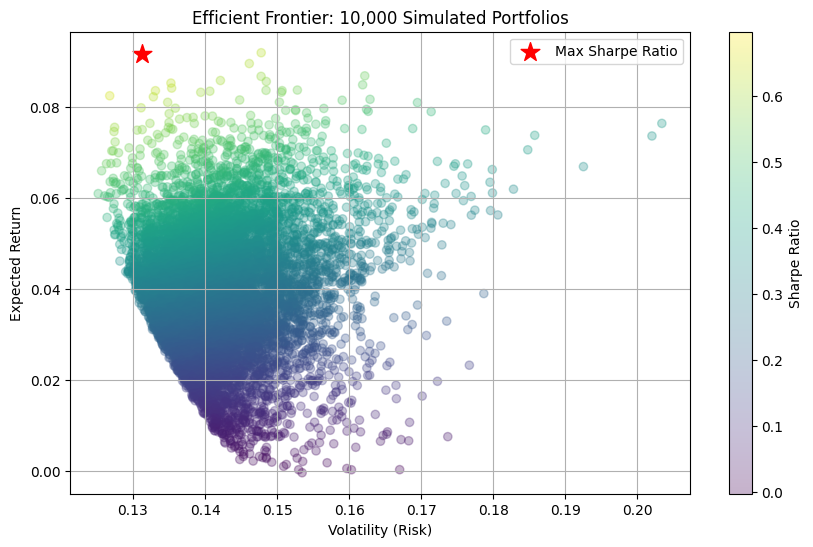

In [4]:
plt.figure(figsize=(10, 6))
# Plot the 10,000 simulated portfolios
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

# Mark the Optimal Portfolio (Max Sharpe) with a red star
plt.scatter(vol_arr[max_sharpe_idx], ret_arr[max_sharpe_idx], c='red', marker='*', s=200, label='Max Sharpe Ratio')

plt.title('Efficient Frontier: 10,000 Simulated Portfolios')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ... rest of your code ...
# 1. Setup for Constrained Simulation
num_portfolios = 10000
all_weights_con = np.zeros((num_portfolios, len(assets)))
ret_arr_con = np.zeros(num_portfolios)
vol_arr_con = np.zeros(num_portfolios)
sharpe_arr_con = np.zeros(num_portfolios)

for ind in range(num_portfolios):
    # Rule: Generate weights between 0.05 (5%) and 0.35 (35%)
    weights = np.random.uniform(0.05, 0.35, len(assets))
    # Normalize so they sum to exactly 1 (100%)
    weights = weights / np.sum(weights)
    all_weights_con[ind,:] = weights

    ret_arr_con[ind] = np.sum((mean_returns * weights))
    vol_arr_con[ind] = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_arr_con[ind] = ret_arr_con[ind] / vol_arr_con[ind]

# 2. Extract the Constrained "Winner"
max_sharpe_idx_con = sharpe_arr_con.argmax()
best_weights_con = all_weights_con[max_sharpe_idx_con,:]

print("--- Constrained Optimal Weights (Max Sharpe) ---")
for asset, weight in zip(assets, best_weights_con):
    print(f"{asset}: {weight:.2%}")

print(f"\nNew Expected Annual Return: {ret_arr_con[max_sharpe_idx_con]:.2%}")
print(f"New Expected Annual Volatility: {vol_arr_con[max_sharpe_idx_con]:.2%}")

--- Constrained Optimal Weights (Max Sharpe) ---
RELIANCE.NS: 9.25%
TCS.NS: 10.39%
HDFCBANK.NS: 43.78%
HINDUNILVR.NS: 30.11%
NIFTYBEES.NS: 6.48%

New Expected Annual Return: 7.30%
New Expected Annual Volatility: 14.05%


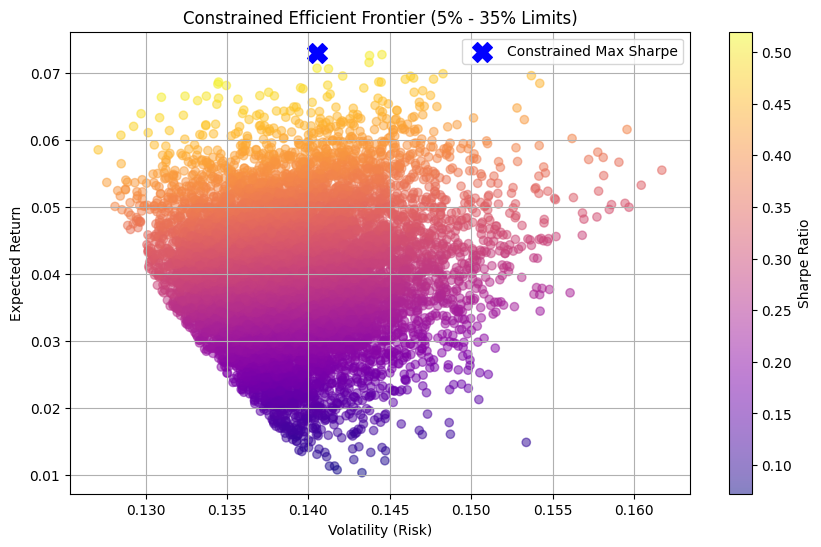

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(vol_arr_con, ret_arr_con, c=sharpe_arr_con, cmap='plasma', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')

# Mark the new Constrained Winner
plt.scatter(vol_arr_con[max_sharpe_idx_con], ret_arr_con[max_sharpe_idx_con],
            c='blue', marker='X', s=200, label='Constrained Max Sharpe')

plt.title('Constrained Efficient Frontier (5% - 35% Limits)')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True)
plt.show()

The blue 'X' represents our Constrained Optimal Portfolio. By imposing a 35% cap on any single asset, we have shifted the portfolio into a more 'defensible' zone.

Expected Return: ~7.30%

Volatility: ~14.05%

Although the return is lower than the unconstrained version, the risk is distributed across Banking, FMCG, and Tech. This demonstrates the transition from purely mathematical optimization to Prudent Risk Management.